# VAR Demo — Historical Simulation VAR for Equities Options Portfolio

End-to-end executable demonstration of the full VAR model.

| Method | Description |
|--------|-------------|
| **A** | Plain Historical Simulation (equal-weight, 252 scenarios) |
| **B** | Age-Weighted HS (exponential decay λ=0.97) |
| **D** | Factor-Based VAR (systematic + idiosyncratic decomposition) |
| **SVaR** | Stressed VAR (worst 252-day rolling window — Basel 2.5) |

All VAR and ES figures use the **loss convention** (positive number = loss).

**Sections:** Setup → Data → Vol Surface → Portfolio → Scenarios → Pricing → P&L
→ Plain HS VAR → Age-Weighted VAR → Factor VAR → Stress VAR → Backtest → Summary


In [1]:
import sys
import pathlib
import warnings
warnings.filterwarnings("ignore")

# Resolve src/ — works whether notebook is launched from project root or notebooks/
_root = pathlib.Path.cwd()
for _p in [_root / "src", _root.parent / "src"]:
    if _p.exists():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)

print("src on path:", sys.path[0])


src on path: /Volumes/ExternalSSD/Users/Mijan/projects/var_demo/src


---
## 1 · Synthetic Data Generation

We simulate **5 years** of daily equity prices for 5 large-cap stocks and 1 market
index using Geometric Brownian Motion (GBM) with correlated shocks.

| Ticker | S₀     | μ (ann.) | σ (ann.) | ρ to SPX |
|--------|--------|----------|----------|----------|
| AAPL   | 180    | 12%      | 25%      | 0.60     |
| MSFT   | 380    | 10%      | 22%      | 0.65     |
| GOOGL  | 140    | 11%      | 28%      | 0.70     |
| AMZN   | 175    | 13%      | 30%      | 0.75     |
| META   | 400    | 15%      | 35%      | 0.80     |
| SPX    | 4 500  | 8%       | 16%      | 1.00     |


In [2]:
N_DAYS = 1_300   # ~5 years of business days
SEED   = 42
rng    = np.random.default_rng(SEED)
dt     = 1.0 / 252

# ── Market factor (SPX) ──────────────────────────────────────────────────────
MU_SPX, SIG_SPX, S0_SPX = 0.08, 0.16, 4_500.0
spx_shocks  = rng.standard_normal(N_DAYS)
spx_log_ret = (MU_SPX - 0.5 * SIG_SPX**2) * dt + SIG_SPX * np.sqrt(dt) * spx_shocks

# ── Equity returns — correlated to SPX via factor model ──────────────────────
EQ_PARAMS = {
    #            S0      mu     sig    rho
    "AAPL": (180.0,  0.12,  0.25,  0.60),
    "MSFT": (380.0,  0.10,  0.22,  0.65),
    "GOOGL":(140.0,  0.11,  0.28,  0.70),
    "AMZN": (175.0,  0.13,  0.30,  0.75),
    "META": (400.0,  0.15,  0.35,  0.80),
}
idio_shocks = rng.standard_normal((N_DAYS, len(EQ_PARAMS)))

eq_log_rets = {}
for i, (ticker, (s0, mu, sig, rho)) in enumerate(EQ_PARAMS.items()):
    shock = rho * spx_shocks + np.sqrt(max(1 - rho**2, 0)) * idio_shocks[:, i]
    eq_log_rets[ticker] = (mu - 0.5 * sig**2) * dt + sig * np.sqrt(dt) * shock

# ── Build price DataFrames (N_DAYS + 1 price points → N_DAYS returns) ────────
dates = pd.bdate_range("2019-01-02", periods=N_DAYS + 1)

eq_price_dict = {}
for ticker, (s0, *_) in EQ_PARAMS.items():
    lr = eq_log_rets[ticker]
    eq_price_dict[ticker] = np.concatenate([[s0], s0 * np.exp(np.cumsum(lr))])

equity_prices = pd.DataFrame(eq_price_dict, index=dates)
index_prices  = pd.DataFrame(
    {"SPX": np.concatenate([[S0_SPX], S0_SPX * np.exp(np.cumsum(spx_log_ret))])},
    index=dates,
)

as_of = equity_prices.index[-1]

print(f"Date range : {dates[0].date()}  →  {dates[-1].date()}")
print(f"Observations: {N_DAYS + 1} price points, {N_DAYS} daily returns")
print(f"Valuation date (as_of): {as_of.date()}")
print("\nFinal spot prices:")
print(equity_prices.iloc[-1].round(2).to_string())


Date range : 2019-01-02  →  2023-12-27
Observations: 1301 price points, 1300 daily returns
Valuation date (as_of): 2023-12-27

Final spot prices:
AAPL     131.46
MSFT     548.76
GOOGL     85.19
AMZN     160.77
META     409.06


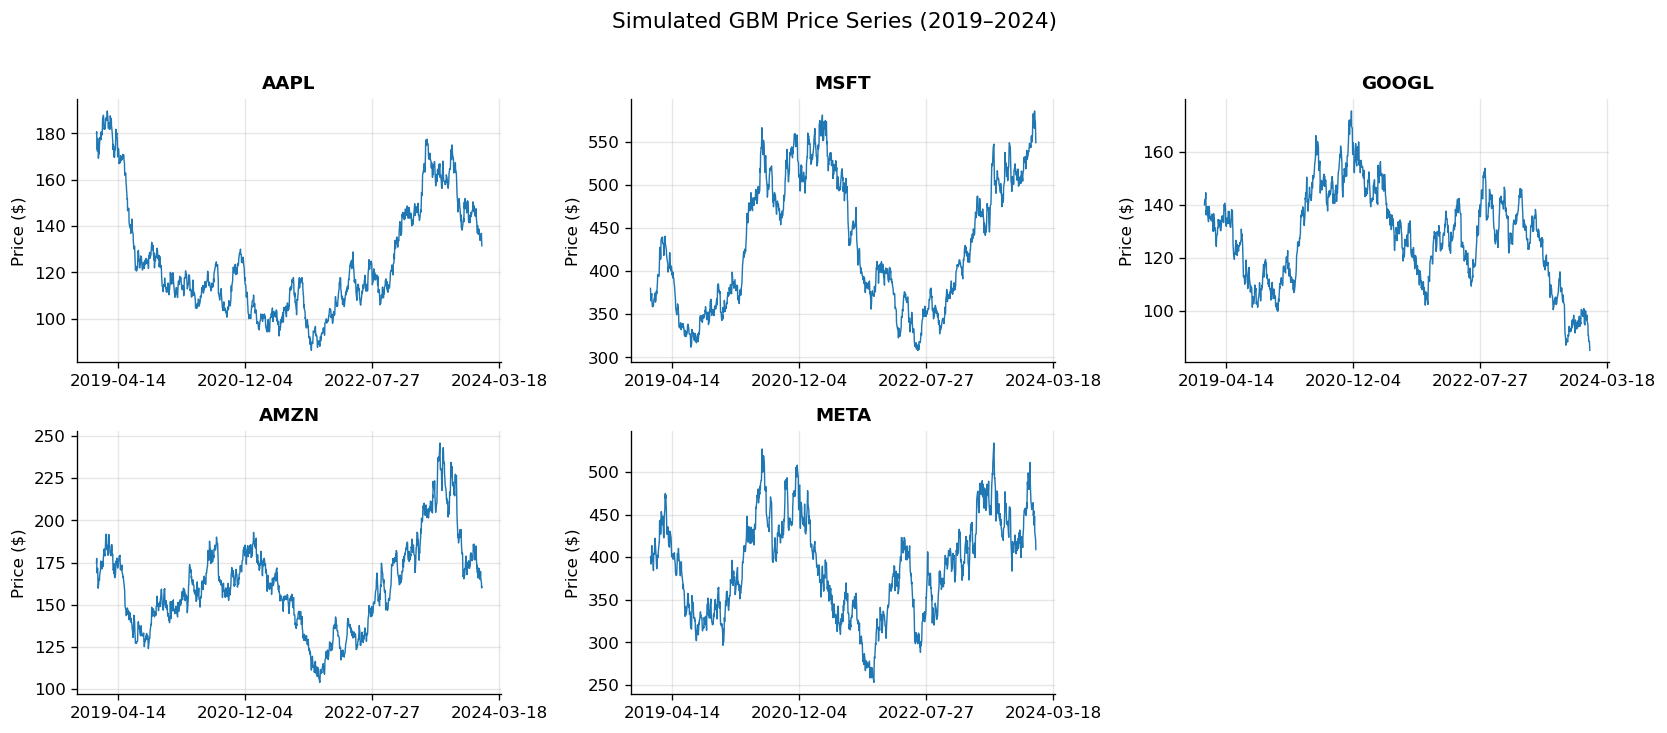

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()
all_tickers = list(EQ_PARAMS.keys()) + ["SPX"]
all_px = pd.concat([equity_prices, index_prices], axis=1)

for ax, ticker in zip(axes, all_tickers):
    ax.plot(all_px.index, all_px[ticker], linewidth=0.85)
    ax.set_title(ticker, fontsize=11, fontweight="bold")
    ax.set_ylabel("Price ($)")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(4))

axes[-1].set_visible(False)
fig.suptitle("Simulated GBM Price Series (2019–2024)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---
## 2 · Volatility Surface

Rolling realised volatility is used as the ATM implied volatility proxy,
matched to option tenor:

| Window | Duration | Used when T < … |
|--------|----------|-----------------|
| Short  | 21 days  | 3 months        |
| Medium | 63 days  | 6 months        |
| Long   | 126 days | always          |

A **quadratic skew** in log-moneyness then generates the full strike surface:

$$\sigma(K, T) = \sigma_{ATM}(T) + \alpha \cdot k + \beta \cdot k^2, \quad
  k = \ln\!\left(\frac{K}{F}\right), \quad F = S e^{rT}$$

with α = −0.15 (negative skew — downside puts more expensive) and β = 0.05 (smile).


In [4]:
from data.vol_surface import (
    compute_rolling_vol,
    get_atm_vol,
    skew_vol,
    VOL_WINDOWS,
)

rolling_vols = compute_rolling_vol(equity_prices)

print(f"Rolling vol windows: {VOL_WINDOWS}")
print(f"\nATM vols for AAPL on {as_of.date()} (tenor-matched):")

# get_atm_vol selects window by T_remaining (float in years)
tenors = {"3-month (T=0.25)": 0.25, "6-month (T=0.50)": 0.50, "1-year  (T=1.00)": 1.00}
for label, T in tenors.items():
    v = get_atm_vol(rolling_vols, "AAPL", as_of, T_remaining=T)
    print(f"  {label}: {v:.1%}")


Rolling vol windows: {'short': 21, 'medium': 63, 'long': 126}

ATM vols for AAPL on 2023-12-27 (tenor-matched):
  3-month (T=0.25): 24.9%
  6-month (T=0.50): 24.3%
  1-year  (T=1.00): 24.3%


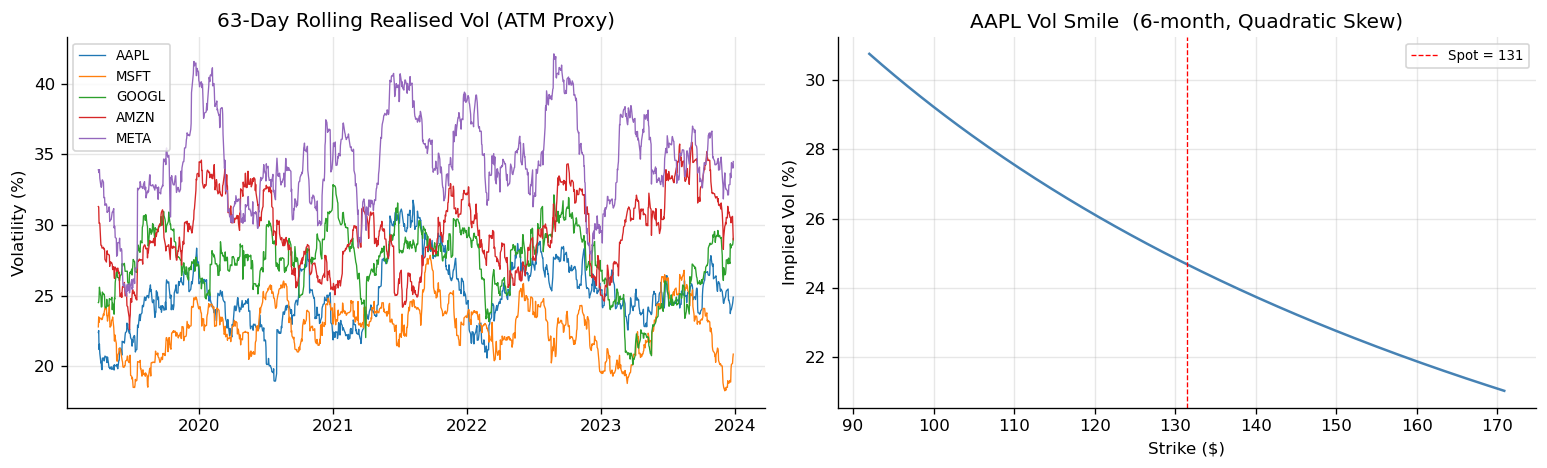

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: rolling medium-window vol for all equities
ax = axes[0]
for ticker in EQ_PARAMS:
    s = rolling_vols["medium"][ticker].dropna()
    ax.plot(s.index, s * 100, linewidth=0.8, label=ticker)
ax.set_title("63-Day Rolling Realised Vol (ATM Proxy)")
ax.set_ylabel("Volatility (%)")
ax.legend(fontsize=8)

# Right: vol smile at as_of for AAPL (6-month expiry)
ax = axes[1]
S_demo  = float(equity_prices.loc[as_of, "AAPL"])
T_demo  = 0.5      # 6-month option
r_demo  = 0.05
alpha_s, beta_s = -0.15, 0.05

atm_vol = get_atm_vol(rolling_vols, "AAPL", as_of, T_remaining=T_demo)
K_range = np.linspace(S_demo * 0.70, S_demo * 1.30, 200)
# skew_vol(atm_vol, K, S, r, T, alpha, beta)
smile   = [skew_vol(atm_vol, K, S_demo, r_demo, T_demo, alpha_s, beta_s) * 100
           for K in K_range]

ax.plot(K_range, smile, color="steelblue")
ax.axvline(S_demo, color="red", linestyle="--", linewidth=0.8,
           label=f"Spot = {S_demo:.0f}")
ax.set_title("AAPL Vol Smile  (6-month, Quadratic Skew)")
ax.set_xlabel("Strike ($)")
ax.set_ylabel("Implied Vol (%)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## 3 · Portfolio Generation

We generate **50 synthetic European options** (calls and puts, longs and shorts)
across the 5 equity underlyings. Strikes are within ±20% of spot; expiries range
from 3 to 12 months. Premium is priced at fair value using the vol surface.


In [6]:
from data.portfolio import generate_portfolio

today_prices = equity_prices.loc[as_of]   # spot prices for equities only

trades = generate_portfolio(
    spot_prices  = today_prices,
    n_trades     = 50,
    r            = 0.05,
    as_of        = as_of,
    seed         = SEED,
    rolling_vols = rolling_vols,
    alpha        = -0.15,
    beta         =  0.05,
)

print(f"Generated {len(trades)} trades")
print("\nComposition by underlying / option_type / position_sign:")
print(
    trades.groupby(["underlying", "option_type", "position_sign"])
    .size()
    .rename("count")
    .reset_index()
    .to_string(index=False)
)


Generated 50 trades

Composition by underlying / option_type / position_sign:
underlying option_type  position_sign  count
      AAPL        call             -1      3
      AAPL         put             -1      3
      AAPL         put              1      1
      AMZN        call             -1      2
      AMZN        call              1      5
      AMZN         put             -1      4
      AMZN         put              1      2
     GOOGL        call             -1      3
     GOOGL        call              1      1
     GOOGL         put             -1      1
     GOOGL         put              1      8
      META        call             -1      2
      META        call              1      4
      META         put              1      1
      MSFT        call             -1      3
      MSFT        call              1      2
      MSFT         put             -1      3
      MSFT         put              1      2


In [7]:
display_cols = [
    "trade_id", "underlying", "option_type",
    "strike", "expiry", "notional", "position_sign", "premium",
]
(
    trades[display_cols]
    .head(10)
    .style
    .format({"strike": "{:.1f}", "premium": "{:.4f}"})
    .set_caption("First 10 Trades (of 50)")
)


,trade_id,underlying,option_type,strike,expiry,notional,position_sign,premium
0,OPT-001,AAPL,put,150.3,2024-06-20 00:00:00,100,-1,18.5909
1,OPT-002,AMZN,call,191.4,2024-09-17 00:00:00,500,1,7.6285
2,OPT-003,AMZN,put,157.6,2024-03-25 00:00:00,200,-1,7.5205
3,OPT-004,MSFT,call,580.3,2024-06-20 00:00:00,500,-1,23.3600
4,OPT-005,GOOGL,call,87.0,2024-03-25 00:00:00,500,1,4.6340
5,OPT-006,AAPL,put,138.4,2024-03-25 00:00:00,500,-1,9.2004
6,OPT-007,AMZN,call,186.1,2024-12-13 00:00:00,500,1,12.3015
7,OPT-008,AMZN,put,158.6,2024-06-20 00:00:00,100,1,10.1346
8,OPT-009,GOOGL,call,93.5,2024-09-17 00:00:00,200,-1,5.6266
9,OPT-010,META,call,387.9,2024-03-25 00:00:00,200,1,42.4350


---
## 4 · Scenario Construction

The VAR scenario set = the **252 most recent daily log-returns**.
Each row represents a historical one-day joint shock applied to today's spots.


In [8]:
from var.scenarios import (
    compute_log_returns,
    build_scenario_set,
    build_stressed_price_matrix,
    build_age_weights,
)

log_returns  = compute_log_returns(equity_prices)
scenario_set = build_scenario_set(log_returns, lookback=252)

print(f"Total log-return observations : {len(log_returns)}")
print(f"Scenario set shape (N×tickers): {scenario_set.shape}")
print(f"Scenario date range: {scenario_set.index[0].date()} → {scenario_set.index[-1].date()}")
print("\nScenario summary (% daily returns):")
(scenario_set * 100).describe().round(3)


Total log-return observations : 1300
Scenario set shape (N×tickers): (252, 5)
Scenario date range: 2023-01-10 → 2023-12-27

Scenario summary (% daily returns):


,AAPL,MSFT,GOOGL,AMZN,META
count,252.000,252.000,252.000,252.000,252.000
mean,-0.049,0.122,-0.177,-0.060,0.012
std,1.556,1.435,1.602,2.011,2.198
min,-3.925,-3.952,-4.985,-4.908,-4.990
25%,-1.068,-0.834,-1.313,-1.435,-1.503
50%,-0.128,0.067,-0.158,-0.084,0.042
75%,0.996,1.104,0.937,1.352,1.741
max,4.897,4.073,3.829,6.705,7.399


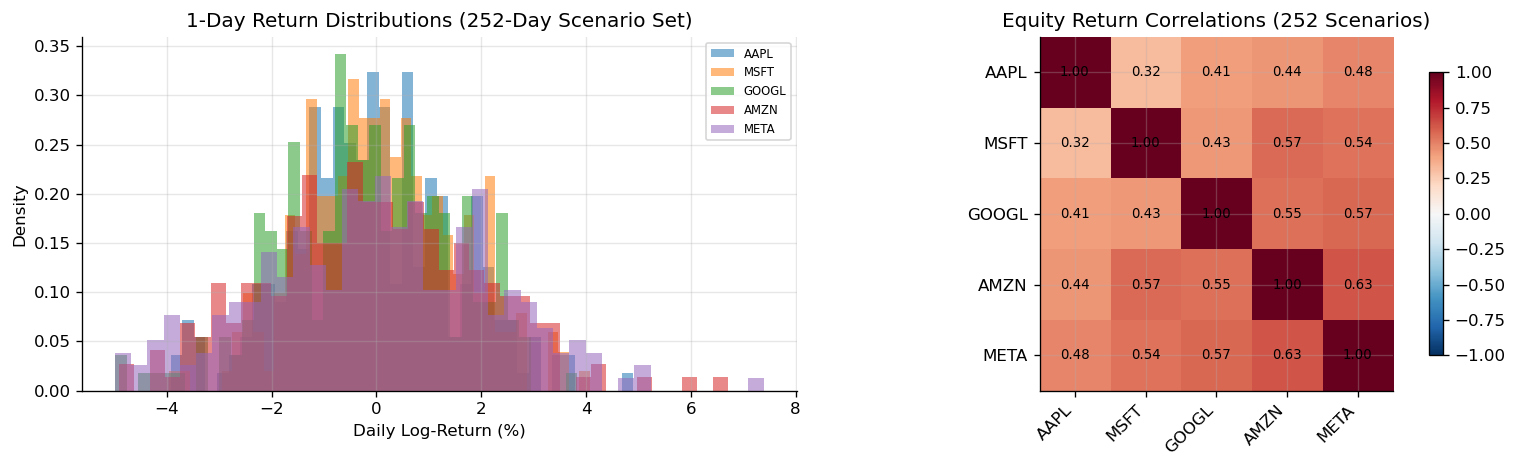

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: return distributions
ax = axes[0]
for ticker in EQ_PARAMS:
    ax.hist(scenario_set[ticker] * 100, bins=40, alpha=0.55, label=ticker, density=True)
ax.set_xlabel("Daily Log-Return (%)")
ax.set_ylabel("Density")
ax.set_title("1-Day Return Distributions (252-Day Scenario Set)")
ax.legend(fontsize=7)

# Right: correlation heatmap
ax = axes[1]
corr = scenario_set.corr()
im   = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax, shrink=0.8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}",
                ha="center", va="center", fontsize=8)
ax.set_title("Equity Return Correlations (252 Scenarios)")

plt.tight_layout()
plt.show()


---
## 5 · Portfolio Pricing & Greeks

Each option is valued using **Black-Scholes** with the tenor-matched vol surface
calibrated on `as_of`.

**Position value** = unit BS price × notional × position_sign


In [10]:
from data.portfolio import price_portfolio, portfolio_greeks

priced    = price_portfolio(trades, today_prices, rolling_vols, r=0.05, as_of=as_of)
greeks_df = portfolio_greeks(trades, today_prices, rolling_vols, r=0.05, as_of=as_of)

today_values = priced.set_index("trade_id")["position_value"]
total_npv    = today_values.sum()

print(f"Portfolio NPV: ${total_npv:,.0f}")
print(f"Long  trades (position_sign=+1): {(trades['position_sign']==1).sum()}")
print(f"Short trades (position_sign=-1): {(trades['position_sign']==-1).sum()}")
print("\nPosition value distribution:")
print(priced["position_value"].describe().round(2))


Portfolio NPV: $-17,069
Long  trades (position_sign=+1): 26
Short trades (position_sign=-1): 24

Position value distribution:
count       50.00
mean      -341.37
std       6024.91
min     -17134.25
25%      -2056.91
50%        177.70
75%       2259.13
max      16673.90
Name: position_value, dtype: float64


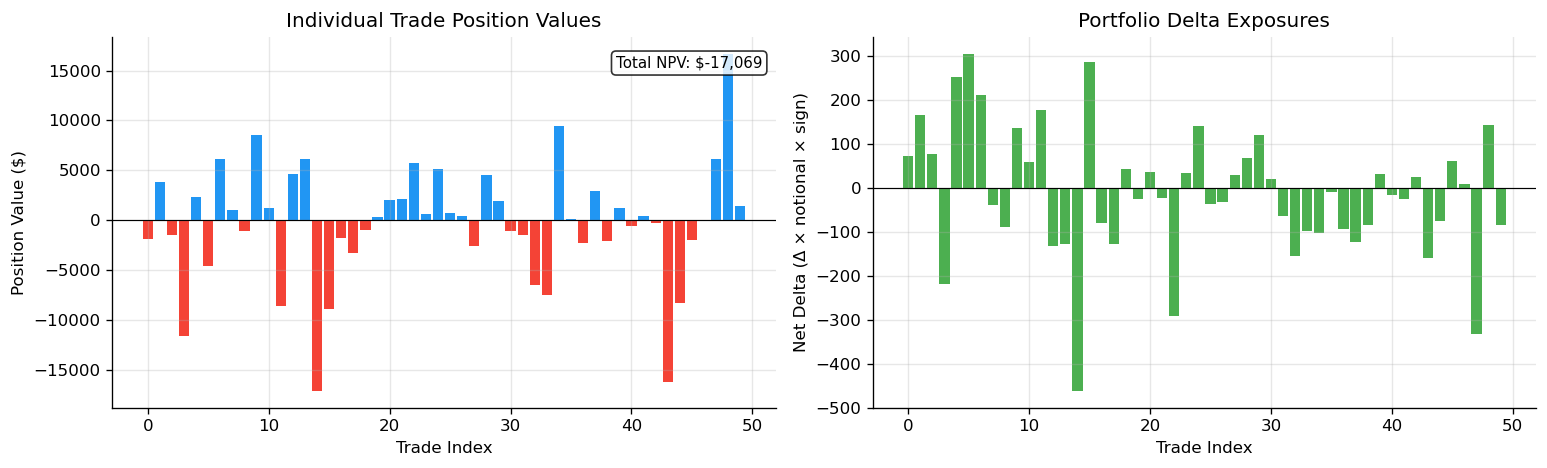

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: individual position values
ax = axes[0]
colors = ["#2196F3" if v >= 0 else "#F44336" for v in today_values.values]
ax.bar(range(len(today_values)), today_values.values, color=colors, width=0.85)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_xlabel("Trade Index")
ax.set_ylabel("Position Value ($)")
ax.set_title("Individual Trade Position Values")
ax.text(
    0.98, 0.95, f"Total NPV: ${total_npv:,.0f}",
    transform=ax.transAxes, ha="right", va="top", fontsize=9,
    bbox=dict(boxstyle="round", fc="w", alpha=0.8),
)

# Right: net delta exposure per trade
ax = axes[1]
net_delta = (
    greeks_df["delta"].values
    * trades["notional"].values
    * trades["position_sign"].values
)
ax.bar(range(len(net_delta)), net_delta, color="#4CAF50", width=0.85)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_xlabel("Trade Index")
ax.set_ylabel("Net Delta (Δ × notional × sign)")
ax.set_title("Portfolio Delta Exposures")

plt.tight_layout()
plt.show()


---
## 6 · P&L Distribution (Full Revaluation)

Each of the 252 historical scenarios is applied to today's spot prices.
The portfolio is **fully repriced** under each stressed scenario using Black-Scholes.
The resulting 252 P&L values form the empirical loss distribution used for VAR.


In [12]:
from var.revaluation import full_reprice_pnl
from utils.stats import compute_var_es

scenario_prices = build_stressed_price_matrix(today_prices, scenario_set)
pnl_vec = full_reprice_pnl(
    trades, today_prices, today_values, scenario_prices,
    rolling_vols, r=0.05, as_of=as_of,
)

print(f"P&L vector length: {len(pnl_vec)} (one per scenario)")
print(f"Worst loss (min P&L): ${pnl_vec.min():,.0f}")
print(f"Best gain (max P&L):  ${pnl_vec.max():,.0f}")
print(f"Mean P&L:             ${pnl_vec.mean():,.0f}")
print(f"P&L std:              ${pnl_vec.std():,.0f}")


P&L vector length: 252 (one per scenario)
Worst loss (min P&L): $-9,640
Best gain (max P&L):  $6,055
Mean P&L:             $-1,799
P&L std:              $3,502


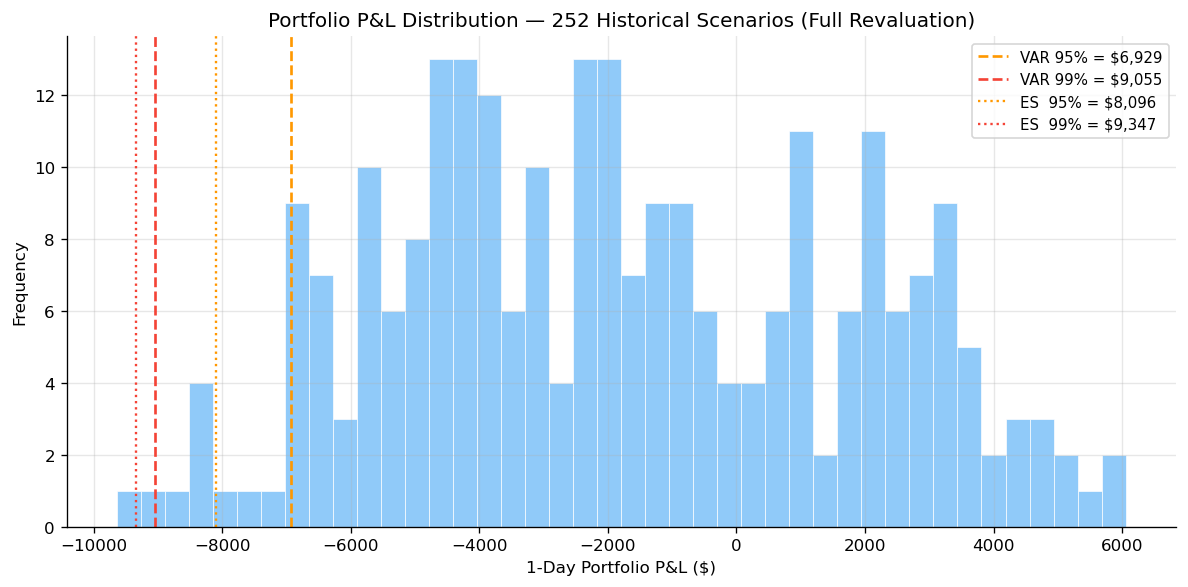

In [13]:
# Quick VAR/ES preview for the histogram
_preview = compute_var_es(pnl_vec, [0.95, 0.99])
var95, es95 = _preview["var_95"], _preview["es_95"]
var99, es99 = _preview["var_99"], _preview["es_99"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(pnl_vec, bins=42, color="#90CAF9", edgecolor="white", linewidth=0.4)
ax.axvline(-var95, color="#FF9800", linestyle="--", linewidth=1.6,
           label=f"VAR 95% = ${var95:,.0f}")
ax.axvline(-var99, color="#F44336", linestyle="--", linewidth=1.6,
           label=f"VAR 99% = ${var99:,.0f}")
ax.axvline(-es95,  color="#FF9800", linestyle=":",  linewidth=1.4,
           label=f"ES  95% = ${es95:,.0f}")
ax.axvline(-es99,  color="#F44336", linestyle=":",  linewidth=1.4,
           label=f"ES  99% = ${es99:,.0f}")
ax.set_xlabel("1-Day Portfolio P&L ($)")
ax.set_ylabel("Frequency")
ax.set_title("Portfolio P&L Distribution — 252 Historical Scenarios (Full Revaluation)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## 7 · Method A — Plain Historical Simulation VAR

Every scenario carries equal probability 1/N.

- **VAR(α)**: loss exceeded in ⌊N(1−α)⌋ worst scenarios
- **ES(α)**: mean loss across those ⌊N(1−α)⌋ worst scenarios
- **10-day figures**: 1-day × √10 (Basel square-root-of-time rule)


In [14]:
from var.historical_var import compute_historical_var

plain_hs = compute_historical_var(
    trades,
    equity_prices,
    r                 = 0.05,
    as_of             = as_of,
    lookback          = 252,
    confidence_levels = [0.95, 0.99],
    method            = "plain",
)

print("=" * 52)
print("  Method A — Plain Historical Simulation VAR")
print("=" * 52)
for cl in ["95", "99"]:
    print(f"  VAR {cl}%  1d: ${plain_hs[f'var_{cl}']:>12,.0f}")
    print(f"  ES  {cl}%  1d: ${plain_hs[f'es_{cl}']:>12,.0f}")
    print(f"  VAR {cl}% 10d: ${plain_hs[f'var_{cl}_10d']:>12,.0f}")
    print(f"  ES  {cl}% 10d: ${plain_hs[f'es_{cl}_10d']:>12,.0f}")
    print()


  Method A — Plain Historical Simulation VAR
  VAR 95%  1d: $       6,929
  ES  95%  1d: $       8,096
  VAR 95% 10d: $      21,911
  ES  95% 10d: $      25,602

  VAR 99%  1d: $       9,055
  ES  99%  1d: $       9,347
  VAR 99% 10d: $      28,634
  ES  99% 10d: $      29,559



---
## 8 · Method B — Age-Weighted Historical Simulation VAR

Scenarios receive **exponentially decaying weights** (λ = 0.97):

$$w_t \propto \lambda^{T-t}, \quad \sum_{t=1}^{N} w_t = 1$$

More recent observations have higher weight → the model adapts faster to
changing volatility regimes.


  Method B — Age-Weighted HS VAR  (λ = 0.97)
  VAR 95%  plain: $     6,929  age-wtd: $     4,544  diff: -34.4%
  VAR 99%  plain: $     9,055  age-wtd: $     6,929  diff: -23.5%



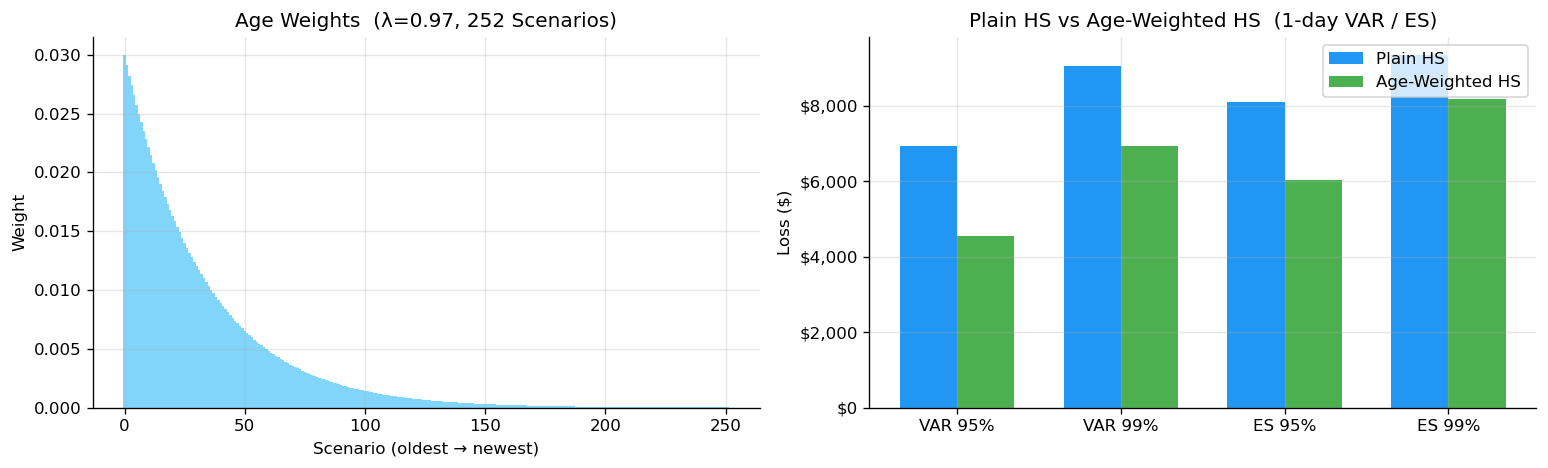

In [15]:
age_hs = compute_historical_var(
    trades,
    equity_prices,
    r                 = 0.05,
    as_of             = as_of,
    lookback          = 252,
    confidence_levels = [0.95, 0.99],
    method            = "age_weighted",
    lambda_           = 0.97,
)

print("=" * 52)
print("  Method B — Age-Weighted HS VAR  (λ = 0.97)")
print("=" * 52)
for cl in ["95", "99"]:
    p_var = plain_hs[f"var_{cl}"]
    a_var = age_hs[f"var_{cl}"]
    chg   = (a_var - p_var) / p_var * 100
    print(
        f"  VAR {cl}%  plain: ${p_var:>10,.0f}  "
        f"age-wtd: ${a_var:>10,.0f}  diff: {chg:+.1f}%"
    )
print()

# Visualise weights + comparison
weights = build_age_weights(252, lambda_=0.97)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(range(252), weights[::-1], color="#81D4FA", width=1.0)
ax.set_xlabel("Scenario (oldest → newest)")
ax.set_ylabel("Weight")
ax.set_title("Age Weights  (λ=0.97, 252 Scenarios)")

ax = axes[1]
labels  = ["VAR 95%", "VAR 99%", "ES 95%", "ES 99%"]
plain_v = [plain_hs["var_95"], plain_hs["var_99"],
           plain_hs["es_95"],  plain_hs["es_99"]]
age_v   = [age_hs["var_95"],   age_hs["var_99"],
           age_hs["es_95"],    age_hs["es_99"]]
x = np.arange(len(labels))
w = 0.35
ax.bar(x - w / 2, plain_v, w, label="Plain HS",        color="#2196F3")
ax.bar(x + w / 2, age_v,   w, label="Age-Weighted HS", color="#4CAF50")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Loss ($)")
ax.set_title("Plain HS vs Age-Weighted HS  (1-day VAR / ES)")
ax.legend()
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v:,.0f}")
)

plt.tight_layout()
plt.show()


---
## 9 · Method D — Factor-Based VAR

Equity returns are decomposed via OLS onto the SPX market factor:

$$r_{i,t} = \alpha_i + \beta_i \cdot F_t + \varepsilon_{i,t}$$

Portfolio P&L is split into two additive components:

| Component | Description |
|-----------|-------------|
| **Systematic** | Delta-gamma on factor-driven price changes (β × SPX shock) |
| **Idiosyncratic** | Delta-gamma on OLS residuals ε_{i,t} |

Both components are combined **scenario-by-scenario** (not Gaussian aggregation),
preserving the full joint tail structure.


In [16]:
from var.factor_var import compute_factor_var

factor_result = compute_factor_var(
    trades,
    equity_prices,
    index_prices,
    r                 = 0.05,
    as_of             = as_of,
    lookback          = 252,
    confidence_levels = [0.95, 0.99],
)

print("=" * 52)
print("  Method D — Factor VAR")
print("=" * 52)
for cl in ["95", "99"]:
    print(f"  VAR {cl}%  1d: ${factor_result[f'var_{cl}']:>12,.0f}")
    print(f"  ES  {cl}%  1d: ${factor_result[f'es_{cl}']:>12,.0f}")

print("\nFactor betas (OLS):")
print(factor_result["factor_betas"].round(4).to_string())


  Method D — Factor VAR
  VAR 95%  1d: $       1,559
  ES  95%  1d: $       1,927
  VAR 99%  1d: $       2,488
  ES  99%  1d: $       2,701

Factor betas (OLS):
         alpha  r_squared     SPX
ticker                           
AAPL   -0.0002     0.3392  0.9232
MSFT    0.0003     0.4112  0.9288
GOOGL  -0.0004     0.5035  1.2294
AMZN   -0.0001     0.5426  1.3814
META    0.0000     0.6487  1.7581


In [17]:
# Decompose into systematic and idiosyncratic components for visualization
from var.factor_var import (
    fit_factor_model,
    compute_factor_pnl,
    compute_residuals,
    compute_idio_pnl,
)

eq_returns  = compute_log_returns(equity_prices)
idx_returns = compute_log_returns(index_prices)

factor_betas  = fit_factor_model(eq_returns, idx_returns)
factor_scens  = build_scenario_set(idx_returns, lookback=252)
greeks        = portfolio_greeks(trades, today_prices, rolling_vols, r=0.05, as_of=as_of)

pnl_factor  = compute_factor_pnl(trades, today_prices, factor_betas, factor_scens, greeks)

residuals    = compute_residuals(eq_returns, idx_returns, factor_betas)
common_dates = residuals.index.intersection(factor_scens.index)
idio_scens   = residuals.loc[common_dates]
pnl_idio     = compute_idio_pnl(trades, today_prices, idio_scens, greeks)

n            = min(len(pnl_factor), len(pnl_idio))
pnl_combined = pnl_factor[:n] + pnl_idio[:n]

# VAR contribution breakdown
var_sys   = compute_var_es(pnl_factor[:n], [0.99])["var_99"]
var_idio  = compute_var_es(pnl_idio[:n],   [0.99])["var_99"]
var_total = compute_var_es(pnl_combined,    [0.99])["var_99"]

print(f"VAR 99%  Systematic:    ${var_sys:>10,.0f}")
print(f"VAR 99%  Idiosyncratic: ${var_idio:>10,.0f}")
print(f"VAR 99%  Combined:      ${var_total:>10,.0f}")
print(f"\nDiversification benefit: ${var_sys + var_idio - var_total:,.0f}")


VAR 99%  Systematic:    $       995
VAR 99%  Idiosyncratic: $     2,154
VAR 99%  Combined:      $     2,488

Diversification benefit: $661


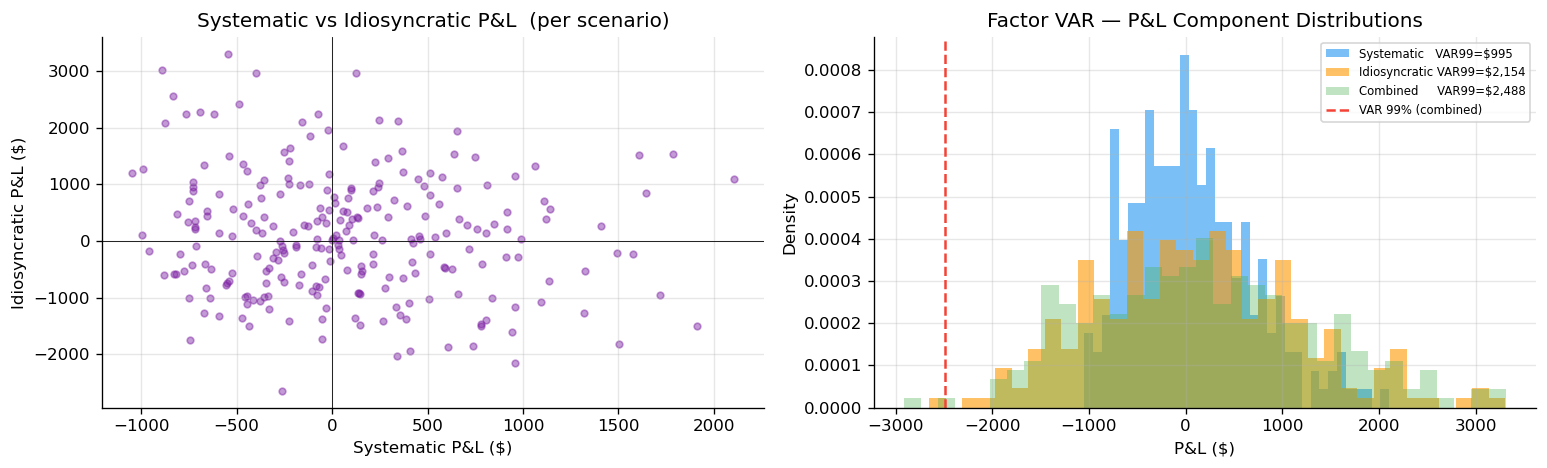

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.scatter(pnl_factor[:n], pnl_idio[:n], alpha=0.45, s=16, c="#7B1FA2")
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Systematic P&L ($)")
ax.set_ylabel("Idiosyncratic P&L ($)")
ax.set_title("Systematic vs Idiosyncratic P&L  (per scenario)")

ax = axes[1]
ax.hist(pnl_factor[:n], bins=35, alpha=0.6, color="#2196F3",
        label=f"Systematic   VAR99=${var_sys:,.0f}", density=True)
ax.hist(pnl_idio[:n],   bins=35, alpha=0.6, color="#FF9800",
        label=f"Idiosyncratic VAR99=${var_idio:,.0f}", density=True)
ax.hist(pnl_combined,   bins=35, alpha=0.35, color="#4CAF50",
        label=f"Combined     VAR99=${var_total:,.0f}", density=True)
ax.axvline(-var_total, color="#F44336", linestyle="--", linewidth=1.5,
           label="VAR 99% (combined)")
ax.set_xlabel("P&L ($)")
ax.set_ylabel("Density")
ax.set_title("Factor VAR — P&L Component Distributions")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


---
## 10 · Stressed VAR (Basel 2.5)

The **Stressed VAR** is computed over the **worst 252-day rolling window** in the
full 5-year history — the period that produces the highest VAR for *this* portfolio.

**Implementation**: A vectorised scan prices all N scenarios in one pass, then uses
a NumPy stride-trick to select the worst rolling window in O(N) operations.


In [19]:
from var.stress_var import compute_stress_var

print("Computing Stressed VAR (scanning full price history) …")
svar = compute_stress_var(
    trades,
    equity_prices,
    r                 = 0.05,
    as_of             = as_of,
    window            = 252,
    confidence_levels = [0.95, 0.99],
)

print(f"\nStress window: {svar['stress_start'].date()}  →  {svar['stress_end'].date()}")
print(f"Scenarios    : {svar['n_scenarios']}")
print()
print("=" * 52)
print("  Stressed VAR (Basel 2.5)")
print("=" * 52)
for cl in ["95", "99"]:
    print(f"  SVaR {cl}%  1d: ${svar[f'var_{cl}']:>12,.0f}")
    print(f"  SES  {cl}%  1d: ${svar[f'es_{cl}']:>12,.0f}")
    print(f"  SVaR {cl}% 10d: ${svar[f'var_{cl}_10d']:>12,.0f}")
    print()


Computing Stressed VAR (scanning full price history) …

Stress window: 2021-06-11  →  2022-05-30
Scenarios    : 252

  Stressed VAR (Basel 2.5)
  SVaR 95%  1d: $       9,126
  SES  95%  1d: $      10,322
  SVaR 95% 10d: $      28,858

  SVaR 99%  1d: $      11,625
  SES  99%  1d: $      11,769
  SVaR 99% 10d: $      36,762



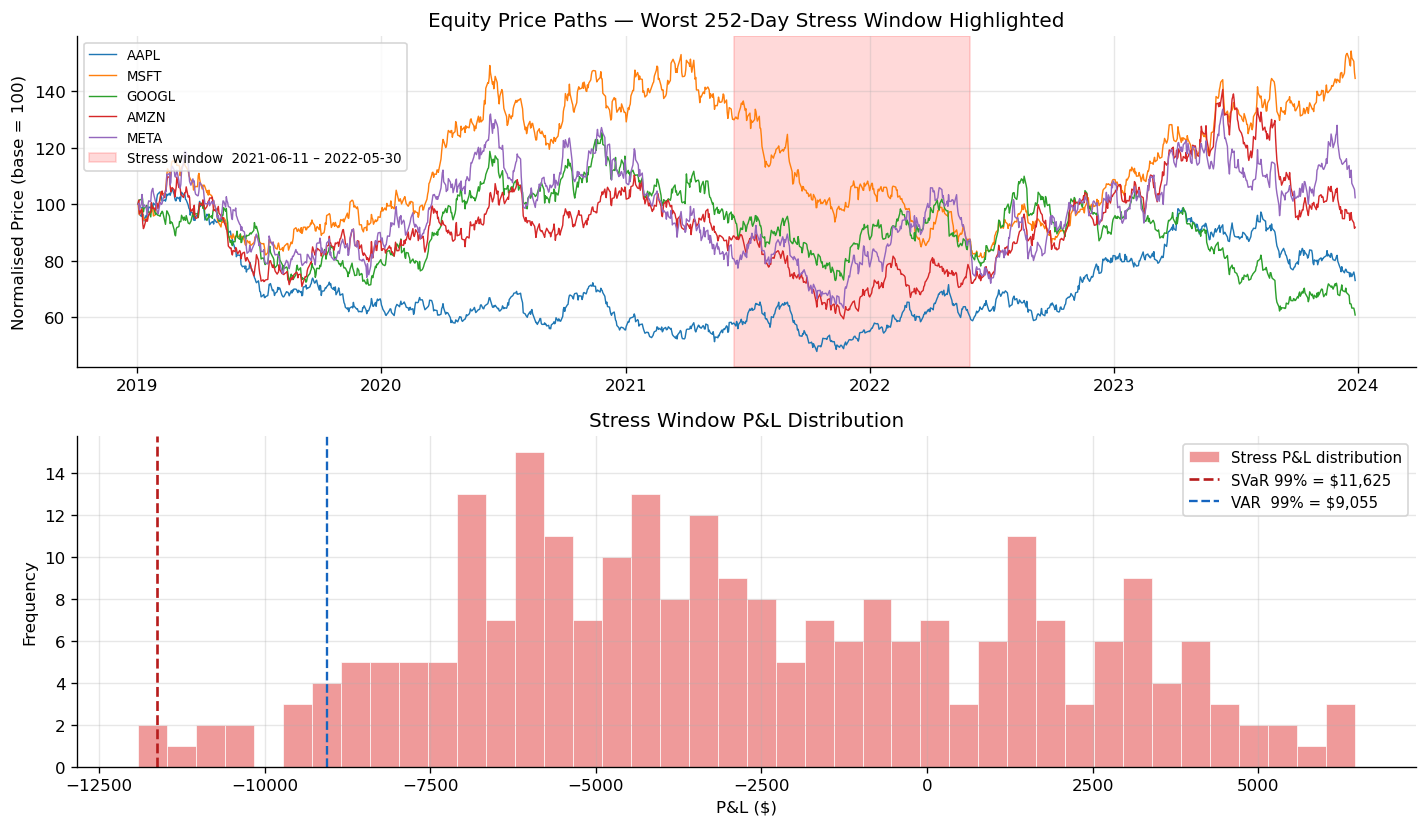

In [20]:
start, end = svar["stress_start"], svar["stress_end"]
svar_pnl   = svar["pnl_vector"]

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Top: price paths with stress period shaded
ax = axes[0]
for ticker in EQ_PARAMS:
    normed = equity_prices[ticker] / equity_prices[ticker].iloc[0] * 100
    ax.plot(normed.index, normed.values, linewidth=0.85, label=ticker)
ax.axvspan(start, end, alpha=0.15, color="red",
           label=f"Stress window  {start.date()} – {end.date()}")
ax.set_ylabel("Normalised Price (base = 100)")
ax.set_title("Equity Price Paths — Worst 252-Day Stress Window Highlighted")
ax.legend(fontsize=8, loc="upper left")

# Bottom: stress window P&L distribution vs current VAR
ax = axes[1]
ax.hist(svar_pnl, bins=42, color="#EF9A9A", edgecolor="white", linewidth=0.4,
        label="Stress P&L distribution")
ax.axvline(-svar["var_99"],   color="#B71C1C", linestyle="--", linewidth=1.6,
           label=f"SVaR 99% = ${svar['var_99']:,.0f}")
ax.axvline(-plain_hs["var_99"], color="#1565C0", linestyle="--", linewidth=1.4,
           label=f"VAR  99% = ${plain_hs['var_99']:,.0f}")
ax.set_xlabel("P&L ($)")
ax.set_ylabel("Frequency")
ax.set_title("Stress Window P&L Distribution")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


---
## 11 · Rolling Backtest & Statistical Validation

For each business day in the test window:
1. Compute 1-day VAR using the preceding 252 scenarios.
2. Record next-day realised P&L.
3. Flag an **exception** when realised loss > VAR.

**Statistical tests:**

| Test | Null Hypothesis |
|------|-----------------|
| Kupiec POF | Exception rate = 1 − CL (unconditional coverage) |
| Christoffersen | Exceptions are i.i.d. (no clustering) |
| Basel traffic light | Green ≤4 / Amber 5–9 / Red ≥10 exceptions |

> Note: `test_window=30` is used here for notebook speed. Production runs use 250 days.


In [21]:
from backtest.backtest import rolling_backtest, backtest_report

TEST_WINDOW = 30   # short for notebook speed; use 250 for production

print(f"Running {TEST_WINDOW}-day rolling backtest …")
bt_df = rolling_backtest(
    trades,
    equity_prices,
    r                 = 0.05,
    lookback          = 252,
    test_window       = TEST_WINDOW,
    confidence_levels = [0.95, 0.99],
)

print(f"Backtest result shape: {bt_df.shape}")
print(f"\nException counts (out of {TEST_WINDOW} days):")
print(f"  At 95% CL: {int(bt_df['exception_95'].sum())} exceptions")
print(f"  At 99% CL: {int(bt_df['exception_99'].sum())} exceptions")
bt_df[["realised_pnl", "var_95", "var_99", "exception_95", "exception_99"]].tail(5).round(0)


Running 30-day rolling backtest …
Backtest result shape: (30, 8)

Exception counts (out of 30 days):
  At 95% CL: 2 exceptions
  At 99% CL: 0 exceptions


,realised_pnl,var_95,var_99,exception_95,exception_99
date,,,,,
2020-07-21,3865.0,6985.0,10572.0,0,0
2020-07-22,-2275.0,6317.0,10161.0,0,0
2020-07-23,-1161.0,6461.0,10180.0,0,0
2020-07-24,-2301.0,6573.0,10235.0,0,0
2020-07-27,-4052.0,4959.0,8576.0,0,0


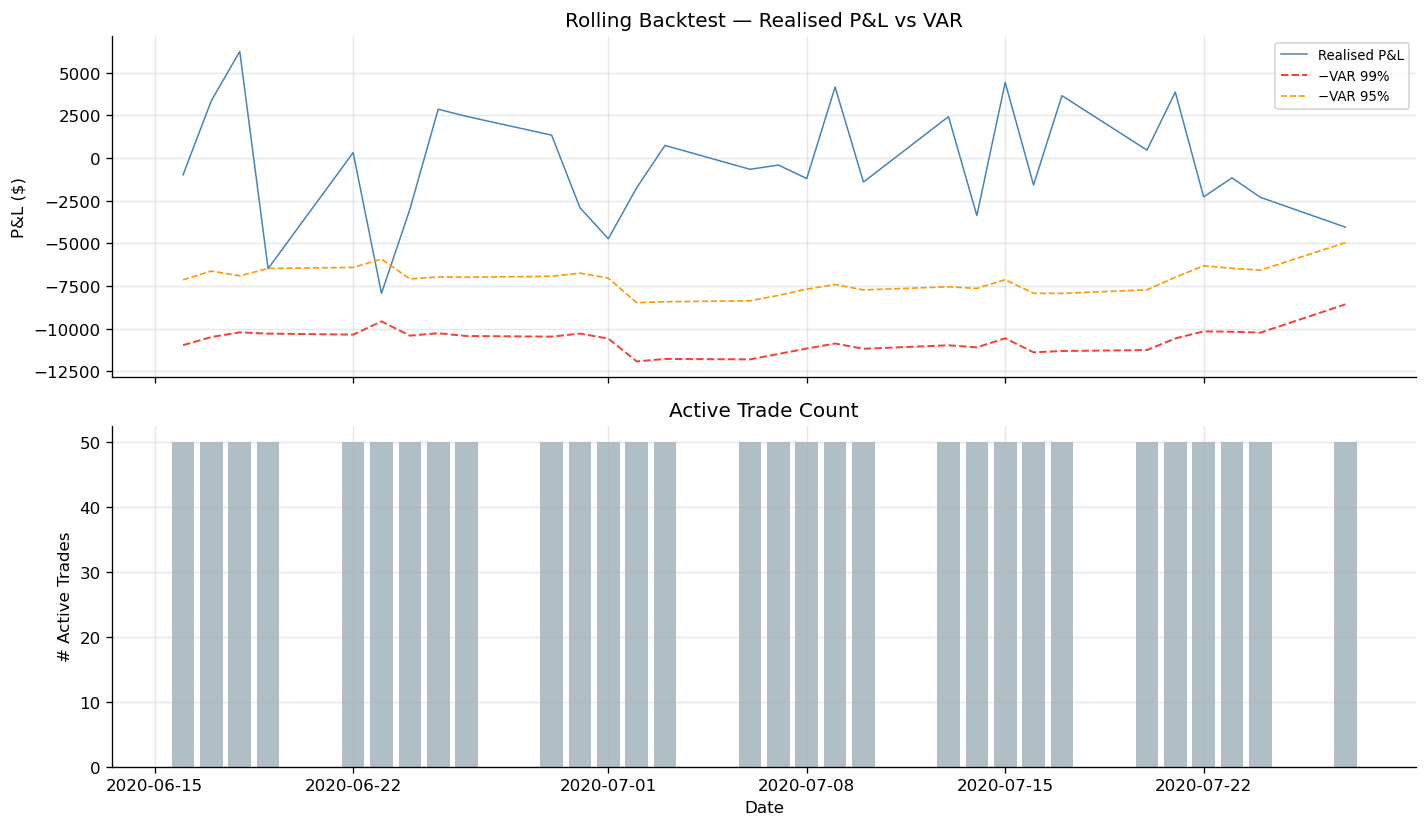

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(bt_df.index, bt_df["realised_pnl"],
        color="steelblue", linewidth=0.9, label="Realised P&L")
ax.plot(bt_df.index, -bt_df["var_99"],
        color="#F44336", linewidth=1.2, linestyle="--", label="−VAR 99%")
ax.plot(bt_df.index, -bt_df["var_95"],
        color="#FF9800", linewidth=1.0, linestyle="--", label="−VAR 95%")
exc99 = bt_df.index[bt_df["exception_99"] == 1]
if len(exc99):
    ax.scatter(exc99, bt_df.loc[exc99, "realised_pnl"],
               color="red", zorder=5, s=55, label="Exception (99%)")
ax.set_ylabel("P&L ($)")
ax.set_title("Rolling Backtest — Realised P&L vs VAR")
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(bt_df.index, bt_df["n_active_trades"], color="#B0BEC5", width=0.8)
ax.set_ylabel("# Active Trades")
ax.set_title("Active Trade Count")
ax.set_xlabel("Date")

plt.tight_layout()
plt.show()


In [23]:
from utils.stats import kupiec_test, christoffersen_test, traffic_light

report = backtest_report(bt_df, confidence_levels=[0.95, 0.99])

print("=" * 68)
print(f"  Backtest Statistical Report  ({TEST_WINDOW}-day window)")
print("=" * 68)

for cl, entry in report.items():
    cl_pct  = int(cl * 100)
    kupiec  = entry["kupiec"]
    christ  = entry["christoffersen"]
    tl      = entry["traffic_light"]

    print(f"\n  ── CL = {cl_pct}% ──")
    print(f"    Observations:         {entry['n_obs']}")
    print(f"    Expected exceptions:  {entry['expected_exceptions']:.1f}")
    print(f"    Actual exceptions:    {entry['n_exceptions']}")
    print(f"    Exception rate:       {entry['exception_rate']:.2%}")
    print(f"    Kupiec p-value:       {kupiec['p_value']:.4f}"
          f"  ({'REJECT H0' if kupiec['reject_h0'] else 'accept H0'})")
    print(f"    Christoffersen p-val: {christ['p_value']:.4f}"
          f"  ({'REJECT H0' if christ['reject_h0'] else 'accept H0'})")
    print(f"    Basel traffic light:  {tl}")


  Backtest Statistical Report  (30-day window)

  ── CL = 95% ──
    Observations:         30
    Expected exceptions:  1.5
    Actual exceptions:    2
    Exception rate:       6.67%
    Kupiec p-value:       0.6896  (accept H0)
    Christoffersen p-val: 0.5860  (accept H0)
    Basel traffic light:  Green

  ── CL = 99% ──
    Observations:         30
    Expected exceptions:  0.3
    Actual exceptions:    0
    Exception rate:       0.00%
    Kupiec p-value:       0.4374  (accept H0)
    Christoffersen p-val: 1.0000  (accept H0)
    Basel traffic light:  Green


---
## 12 · Summary — All VAR Measures Side by Side


In [24]:
summary = pd.DataFrame(
    {
        "Method": [
            "A — Plain HS",
            "B — Age-Weighted HS  (λ=0.97)",
            "D — Factor VAR",
            "SVaR — Stressed VAR  (Basel 2.5)",
        ],
        "VAR 95% 1d": [
            plain_hs["var_95"],
            age_hs["var_95"],
            factor_result["var_95"],
            svar["var_95"],
        ],
        "VAR 99% 1d": [
            plain_hs["var_99"],
            age_hs["var_99"],
            factor_result["var_99"],
            svar["var_99"],
        ],
        "ES 99% 1d": [
            plain_hs["es_99"],
            age_hs["es_99"],
            factor_result["es_99"],
            svar["es_99"],
        ],
        "VAR 99% 10d": [
            plain_hs["var_99_10d"],
            age_hs["var_99_10d"],
            factor_result["var_99_10d"],
            svar["var_99_10d"],
        ],
    }
).set_index("Method")

(
    summary.style
    .format("${:,.0f}")
    .set_caption(f"VAR / ES Summary — Portfolio of {len(trades)} Options  (as_of {as_of.date()})")
)


,VAR 95% 1d,VAR 99% 1d,ES 99% 1d,VAR 99% 10d
Method,,,,
A — Plain HS,"$6,929","$9,055","$9,347","$28,634"
B — Age-Weighted HS (λ=0.97),"$4,544","$6,929","$8,183","$21,911"
D — Factor VAR,"$1,559","$2,488","$2,701","$7,868"
SVaR — Stressed VAR (Basel 2.5),"$9,126","$11,625","$11,769","$36,762"


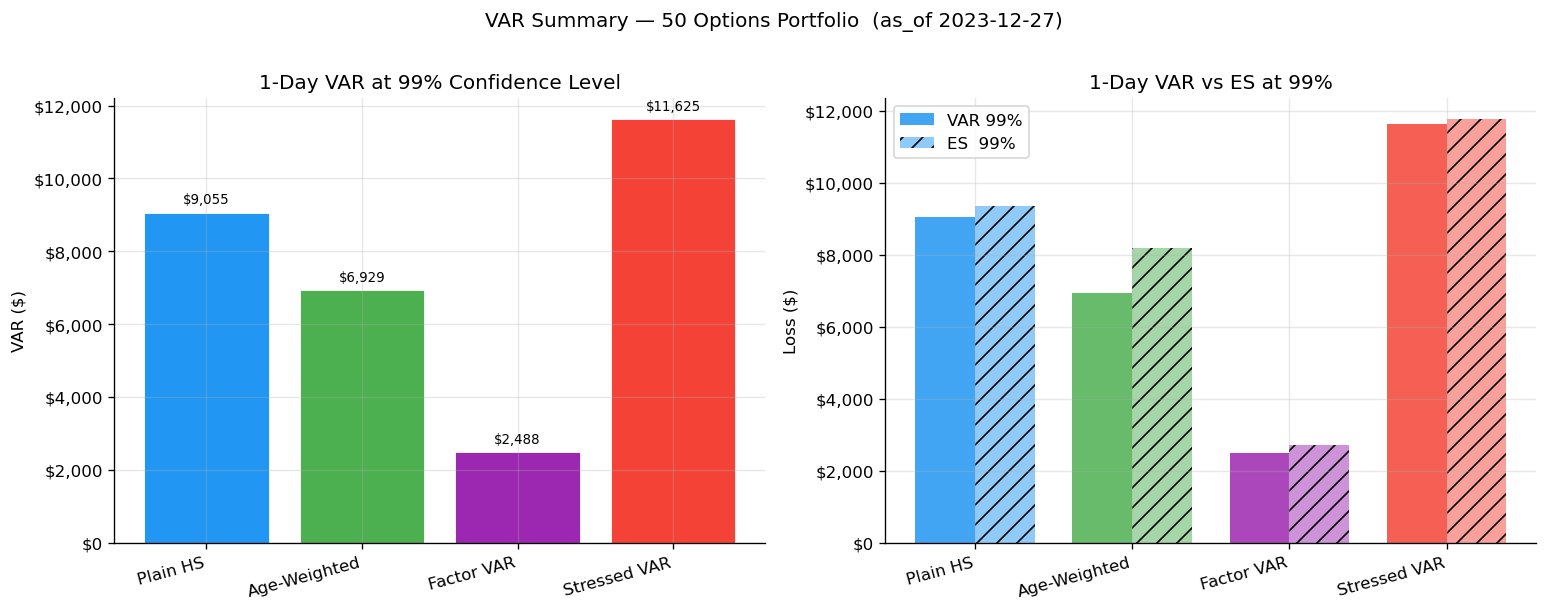

In [25]:
methods = [
    "Plain HS",
    "Age-Weighted",
    "Factor VAR",
    "Stressed VAR",
]
colors  = ["#2196F3", "#4CAF50", "#9C27B0", "#F44336"]
var99_v = [plain_hs["var_99"], age_hs["var_99"],
           factor_result["var_99"], svar["var_99"]]
es99_v  = [plain_hs["es_99"],  age_hs["es_99"],
           factor_result["es_99"],  svar["es_99"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bars = ax.bar(methods, var99_v, color=colors, edgecolor="white", linewidth=0.5)
for bar, v in zip(bars, var99_v):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(var99_v) * 0.015,
        f"${v:,.0f}", ha="center", va="bottom", fontsize=8,
    )
ax.set_title("1-Day VAR at 99% Confidence Level")
ax.set_ylabel("VAR ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.set_xticklabels(methods, rotation=15, ha="right")

ax = axes[1]
x, w = np.arange(len(methods)), 0.38
ax.bar(x - w / 2, var99_v, w, label="VAR 99%", color=colors, alpha=0.85)
ax.bar(x + w / 2, es99_v,  w, label="ES  99%", color=colors, alpha=0.50, hatch="//")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15, ha="right")
ax.set_title("1-Day VAR vs ES at 99%")
ax.set_ylabel("Loss ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.legend()

fig.suptitle(
    f"VAR Summary — {len(trades)} Options Portfolio  (as_of {as_of.date()})",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()


---
## Key Takeaways

| Observation | Detail |
|-------------|--------|
| **ES ≥ VAR always** | Expected Shortfall captures true tail risk beyond VAR |
| **SVaR ≥ Current VAR** | Stress window amplifies tail losses (Basel capital floor) |
| **Factor diversification** | Systematic + idiosyncratic combined benefit vs simple sum |
| **Age-weighting effect** | Shifts weight to recent regimes; diverges in vol transitions |

**Basel 2.5 requirements covered:**
- 1-day VAR at 99% (internal model approval)
- 10-day VAR via √10 scaling
- Stressed VAR from worst historical 252-day window
- Backtest with Kupiec, Christoffersen, and traffic-light validation
